Dielectric Validation

In [18]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob

sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.retrieval.kappa_liquid import kappa_liquid
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.zhu import retrieve_lwc_zhu

In [20]:
in_path = Path("../data/processed/aligned.nc")
ds = xr.open_dataset(in_path)
print(ds)

<xarray.Dataset> Size: 43MB
Dimensions:  (Time: 10441, range: 339)
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB ...
Data variables:
    Ze_W     (Time, range) float32 14MB ...
    Ze_Ka    (Time, range) float32 14MB ...
    T_cloud  (Time, range) float32 14MB ...
Attributes:
    description:  Aligned W/Ka reflectivities + T field for LWC retrieval
    date:         20230928
    site:         Cabauw
    Ze_units:     dBZ
    created_by:   02_align.ipynb


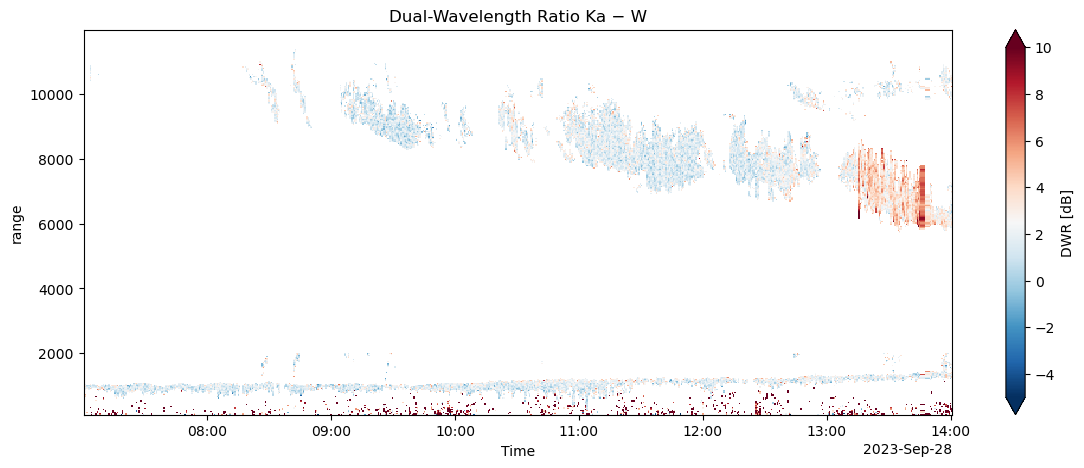

In [21]:
dwr = ds["Ze_Ka"]- ds["Ze_W"]      # in dB
dwr.name = "DWR"
dwr.attrs["units"] = "dB"
fig, ax = plt.subplots(figsize=(14, 5))
dwr.plot(x="Time", y="range", cmap="RdBu_r", vmin=-5, vmax=10, ax=ax, cbar_kwargs={"label": "DWR [dB]"})
ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

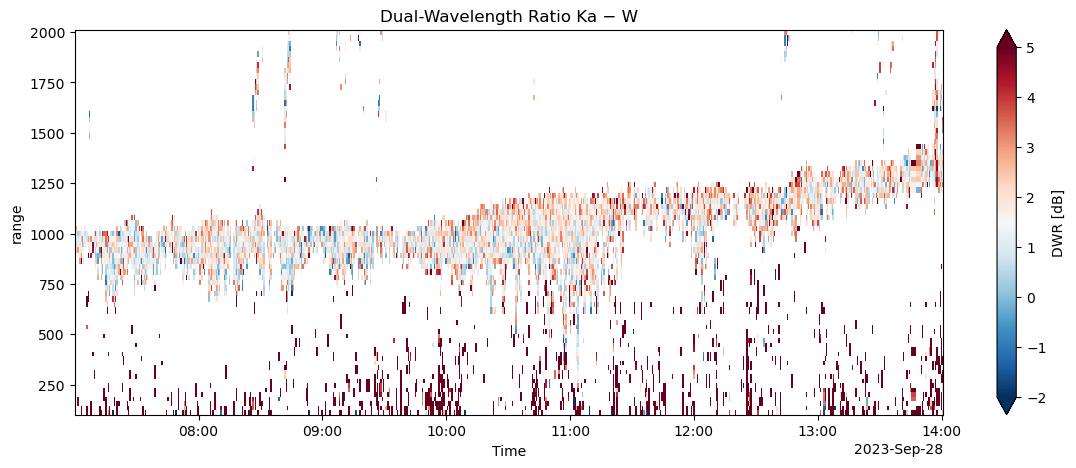

In [51]:
dwr_2km = dwr.sel(range=slice(0, 2000))

fig, ax = plt.subplots(figsize=(14, 5))

dwr_2km.plot(
    x="Time",
    y="range",
    cmap="RdBu_r",
    vmin=-2,
    vmax=5,
    ax=ax,
    cbar_kwargs={"label": "DWR [dB]"}
)

ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

In [48]:
print(float(dwr.min()))
print(float(dwr.max()))

-15.36152458190918
52.93231964111328


In [23]:
eps35 = epsilon_water_liebe1989(35.0, 10.0)
eps94 = epsilon_water_liebe1989(94.0, 10.0)

print(eps35)
print(eps94)

(14.529118996612565-25.186642123507625j)
(6.8077640928799354-10.716147683385891j)


In [24]:
print(kappa_liquid(35.0, 10.0))
print(kappa_liquid(94.0, 10.0))

0.7956729460013171
4.288582543382424


In [25]:
for T in [-20, -10, 0, 10, 20]:
    print(
        T,
        kappa_liquid(35, T),
        kappa_liquid(94, T)
    )

-20 1.6600481771453366 4.425787426921649
-10 1.354247474565436 4.819425687164461
0 1.033342978498033 4.734616820726847
10 0.7956729460013171 4.288582543382424
20 0.633487396048754 3.7586066561320375


In [26]:
cloud_mask = xr.DataArray(
    np.ones_like(dwr.values, dtype=bool),
    dims=dwr.dims,
    coords=dwr.coords,
    name="cloud_mask",
)

In [27]:
alpha_w = xr.DataArray(
    np.full_like(dwr.values, 0.65),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_W",
)

alpha_ka = xr.DataArray(
    np.full_like(dwr.values, 0.14),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_Ka",
)

In [28]:
kappa_w = xr.DataArray(
    np.full_like(dwr.values, 4.29),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_W",
)

kappa_ka = xr.DataArray(
    np.full_like(dwr.values, 0.80),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_Ka",
)

In [29]:
dwr_2km = dwr.sel(range=slice(0, 2000))
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))

alpha_w_2km = alpha_w.sel(range=slice(0, 2000))
alpha_ka_2km = alpha_ka.sel(range=slice(0, 2000))

kappa_w_2km = kappa_w.sel(range=slice(0, 2000))
kappa_ka_2km = kappa_ka.sel(range=slice(0, 2000))

In [30]:
lwc = retrieve_lwc_zhu(
    dwr=dwr_2km,
    kappa_w=kappa_w_2km,
    kappa_ka=kappa_ka_2km,
    alpha_w=alpha_w_2km,
    alpha_ka=alpha_ka_2km,
    cloud_mask=cloud_mask_2km,
    N_default=7,
    min_cloud_gates=3,
)

<xarray.DataArray 'LWC' (Time: 10441, range: 74)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(10441, 74))
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
    TAlt     (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
Attributes:
    units:                      g m-3
    long_name:                  Liquid Water Content (Zhu et al. 2019 retrieval)
    method:                     Sliding-window quadratic DWR gradient
    window_size_default_gates:  7
    min_cloud_gates:            3


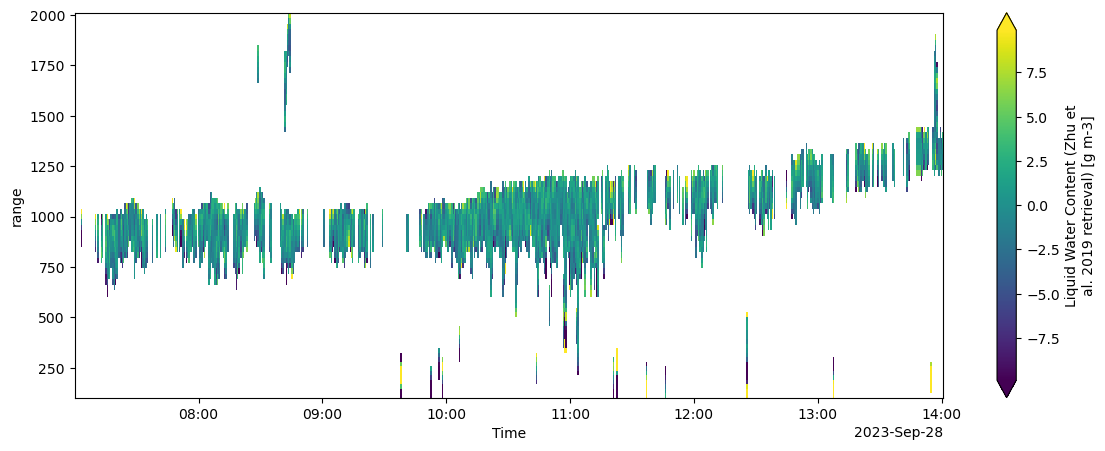

In [31]:
print(lwc)

lwc.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

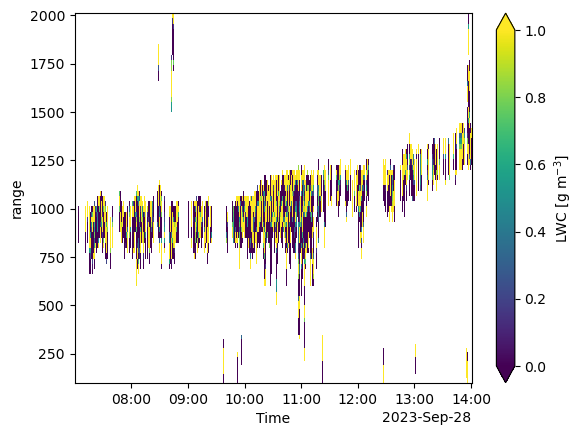

In [32]:
lwc.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

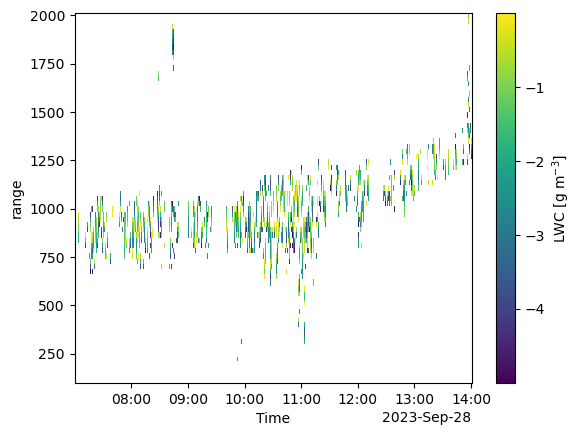

In [41]:
lwc_filtered = lwc.where((lwc >= -5) & (lwc <= 0))
lwc_filtered.plot(
    x="Time",
    y="range",
    cmap="viridis",
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

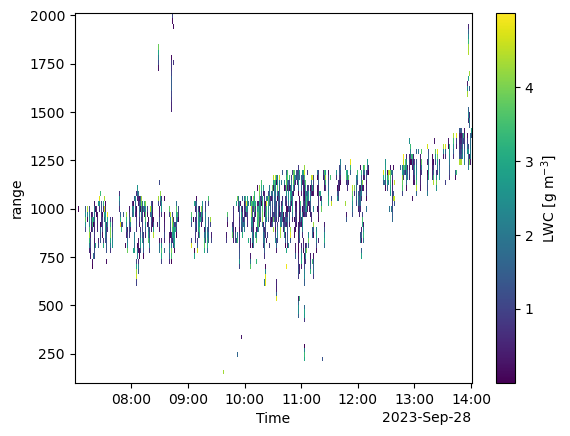

In [47]:
lwc_filtered = lwc.where((lwc >= 0) & (lwc <= 5))
lwc_filtered.plot(
    x="Time",
    y="range",
    cmap="viridis",
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

In [44]:
# Height spacing between radar gates (m)
dz = float(ds["range"].diff("range").mean())
print(f"Gate spacing = {dz:.1f} m")
# Integrate LWC over height
lwp = (lwc * dz).sum(dim="range") /1000

lwp.name = "LWP"
lwp.attrs["units"] = "kg m^-2"

Gate spacing = 35.1 m


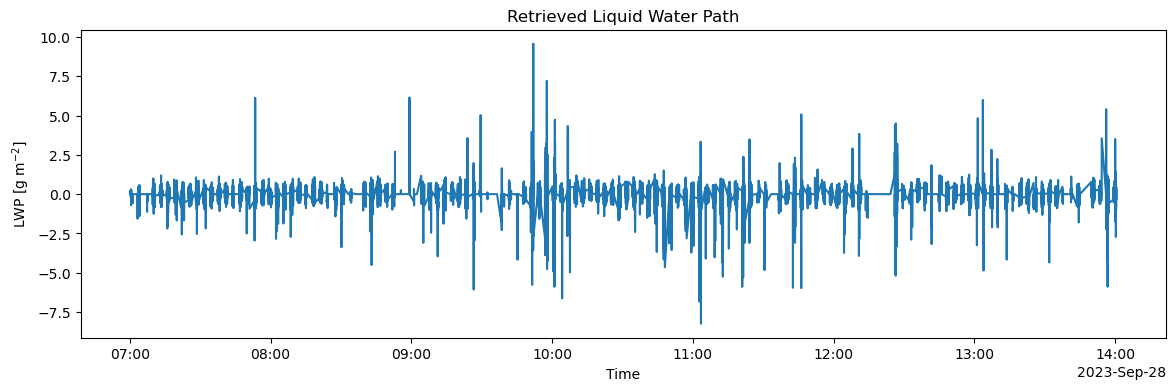

In [45]:
fig, ax = plt.subplots(figsize=(14, 4))

lwp.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path")
ax.set_ylabel("LWP [g m$^{-2}$]")
ax.set_xlabel("Time")

plt.show()

MASKING

In [ ]:
print(float(ze_ka.min()))
print(float(ze_ka.max()))

print(float(ze_w.min()))
print(float(ze_w.max()))